In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import silhouette_score, silhouette_samples
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist, squareform

np.random.seed(42)
print('Libraries imported successfully')

Libraries imported successfully


In [27]:
# Download and extract the Gene Expression Cancer RNA-Seq dataset from UCI
import os, zipfile, tarfile, urllib.request

data_dir = os.path.dirname(os.path.abspath('__file__'))
zip_path = os.path.join(data_dir, 'gene_expression.zip')
extract_dir = os.path.join(data_dir, 'data')

# Step 1: Download and unzip
if not os.path.exists(extract_dir):
    url = 'https://archive.ics.uci.edu/static/public/401/gene+expression+cancer+rna+seq.zip'
    print('Downloading dataset from UCI (this may take a minute)...')
    urllib.request.urlretrieve(url, zip_path)
    print('Extracting zip...')
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(extract_dir)
    os.remove(zip_path)

# Step 2: Extract tar.gz if present
tar_path = os.path.join(extract_dir, 'TCGA-PANCAN-HiSeq-801x20531.tar.gz')
if os.path.exists(tar_path):
    print('Extracting tar.gz...')
    with tarfile.open(tar_path, 'r:gz') as tar:
        tar.extractall(extract_dir)
    os.remove(tar_path)

print('Done. Extracted files:')
for root, dirs, files in os.walk(extract_dir):
    for f in files:
        fpath = os.path.join(root, f)
        size_mb = os.path.getsize(fpath) / (1024 * 1024)
        print(f'  {f} ({size_mb:.1f} MB)')

Done. Extracted files:
  data.csv (196.6 MB)
  labels.csv (0.0 MB)


In [28]:
# Load gene expression data and labels
data_subdir = os.path.join(extract_dir, 'TCGA-PANCAN-HiSeq-801x20531')

X = pd.read_csv(os.path.join(data_subdir, 'data.csv'))
y_df = pd.read_csv(os.path.join(data_subdir, 'labels.csv'))

# Extract labels
y_labels = y_df.iloc[:, 1].values  # second column is the cancer type

# Drop sample ID column from features if present
if X.columns[0] in ['Unnamed: 0', 'sample', 'Sample']:
    X = X.drop(columns=[X.columns[0]])
elif X.iloc[:, 0].dtype == 'object':
    X = X.iloc[:, 1:]

print(f'Expression matrix shape: {X.shape}')
print(f'  Patients (samples):    {X.shape[0]}')
print(f'  Genes (features):      {X.shape[1]}')
print(f'\nUnique cancer types: {np.unique(y_labels)}')
print(f'\nClass distribution:')
for label in sorted(np.unique(y_labels)):
    count = (y_labels == label).sum()
    print(f'  {label:6s}: {count:4d} patients ({count/len(y_labels)*100:.1f}%)')

print(f'\nFirst 5 patients, first 6 genes:')
X.iloc[:5, :6]

Expression matrix shape: (801, 20531)
  Patients (samples):    801
  Genes (features):      20531

Unique cancer types: ['BRCA' 'COAD' 'KIRC' 'LUAD' 'PRAD']

Class distribution:
  BRCA  :  300 patients (37.5%)
  COAD  :   78 patients (9.7%)
  KIRC  :  146 patients (18.2%)
  LUAD  :  141 patients (17.6%)
  PRAD  :  136 patients (17.0%)

First 5 patients, first 6 genes:


,gene_0,gene_1,gene_2,gene_3,gene_4,gene_5
0,0.0,2.017209,3.265527,5.478487,10.431999,0.0
1,0.0,0.592732,1.588421,7.586157,9.623011,0.0
2,0.0,3.511759,4.327199,6.881787,9.870730,0.0
3,0.0,3.663618,4.507649,6.659068,10.196184,0.0
4,0.0,2.655741,2.821547,6.539454,9.738265,0.0


In [30]:
# Standardize: center each gene to mean=0, std=1
scaler = StandardScaler()
X_raw = X.values
X_standardized = scaler.fit_transform(X_raw)

print('Standardization:')
print(f'  Before -- Mean: {X_raw.mean():.4f}, Std: {X_raw.std():.4f}')
print(f'  After  -- Mean: {X_standardized.mean():.6f}, Std: {X_standardized.std():.4f}')
print(f'  Shape:   {X_standardized.shape}')

Standardization:
  Before -- Mean: 6.4433, Std: 4.0582
  After  -- Mean: 0.000000, Std: 0.9935
  Shape:   (801, 20531)


In [31]:
# Apply TruncatedSVD with k=50 components
k = 50
svd = TruncatedSVD(n_components=k, random_state=42)
X_reduced = svd.fit_transform(X_standardized)

variance_retained = svd.explained_variance_ratio_.sum()
cumulative_var = np.cumsum(svd.explained_variance_ratio_)

print(f'Dimensionality Reduction with TruncatedSVD:')
print(f'  Original shape:    {X_standardized.shape} ({X_standardized.shape[1]} genes)')
print(f'  Reduced shape:     {X_reduced.shape} ({k} components)')
print(f'  Compression:       {X_standardized.shape[1] // k}x reduction')
print(f'  Variance retained: {variance_retained*100:.2f}%')
print(f'\n  Top components variance:')
for c in [5, 10, 20, 50]:
    print(f'    k={c:3d}: {cumulative_var[c-1]*100:6.2f}%')

Dimensionality Reduction with TruncatedSVD:
  Original shape:    (801, 20531) (20531 genes)
  Reduced shape:     (801, 50) (50 components)
  Compression:       410x reduction
  Variance retained: 63.62%

  Top components variance:
    k=  5:  36.30%
    k= 10:  46.59%
    k= 20:  53.69%
    k= 50:  63.62%


In [32]:
# Compute pairwise distances and Ward linkage
dist_euclidean = pdist(X_reduced, metric='euclidean')
linkage_ward = linkage(X_reduced, method='ward', metric='euclidean')

print(f'Pairwise distances: {len(dist_euclidean)} pairs from {len(X_reduced)} patients')
print(f'  Euclidean range: [{dist_euclidean.min():.2f}, {dist_euclidean.max():.2f}]')
print(f'\nWard linkage matrix shape: {linkage_ward.shape}')

Pairwise distances: 320400 pairs from 801 patients
  Euclidean range: [28.18, 402.69]

Ward linkage matrix shape: (800, 4)


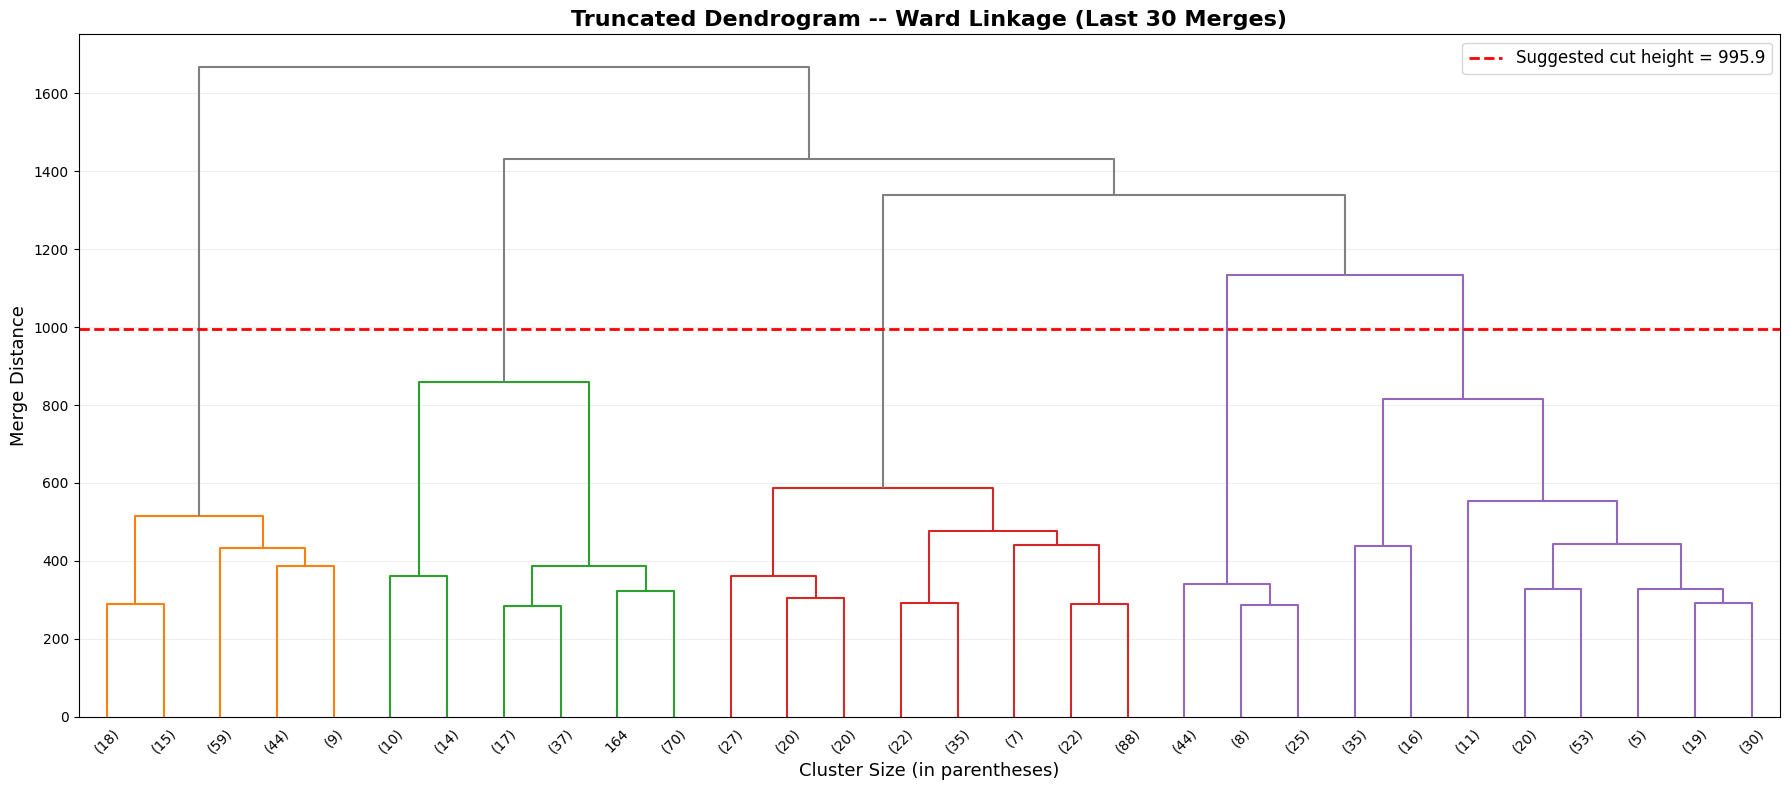

Suggested cut height: 995.86
Interpretation: the largest gap in merge distances indicates
the point where merging would combine genuinely different clusters.


In [33]:
# Truncated dendrogram (Ward) -- clearer view of major cluster structure
fig, ax = plt.subplots(figsize=(18, 8))

dendro_trunc = dendrogram(linkage_ward, ax=ax,
                          truncate_mode='lastp', p=30,
                          color_threshold=0.7 * max(linkage_ward[:, 2]),
                          above_threshold_color='gray')

ax.set_title('Truncated Dendrogram -- Ward Linkage (Last 30 Merges)',
             fontsize=16, fontweight='bold')
ax.set_xlabel('Cluster Size (in parentheses)', fontsize=13)
ax.set_ylabel('Merge Distance', fontsize=13)
ax.grid(True, alpha=0.2, axis='y')

# Mark suggested cut height using largest gap in merge distances
merge_distances = linkage_ward[:, 2]
distance_diffs = np.diff(merge_distances)
cut_idx = np.argmax(distance_diffs[-20:]) + len(distance_diffs) - 20
cut_height = (merge_distances[cut_idx] + merge_distances[cut_idx + 1]) / 2

ax.axhline(y=cut_height, color='red', linestyle='--', linewidth=2,
           label=f'Suggested cut height = {cut_height:.1f}')
ax.legend(fontsize=12)

plt.tight_layout()
plt.show()

print(f'Suggested cut height: {cut_height:.2f}')
print('Interpretation: the largest gap in merge distances indicates')
print('the point where merging would combine genuinely different clusters.')

In [34]:
# Evaluate Silhouette Score for k = 2 to 10
k_range = range(2, 11)
sil_scores = []

print('Silhouette Score for k = 2 to 10:')
print(f'{"k":>4s} | {"Silhouette Score":>16s}')
print('-' * 26)

for n_clusters in k_range:
    cluster_labels = fcluster(linkage_ward, t=n_clusters, criterion='maxclust')
    sil = silhouette_score(X_reduced, cluster_labels)
    sil_scores.append(sil)

    marker = ' <-- true k' if n_clusters == 5 else ''
    print(f'{n_clusters:4d} | {sil:16.4f}{marker}')

best_k = list(k_range)[np.argmax(sil_scores)]
print(f'\nOptimal k by Silhouette Score: {best_k}')

Silhouette Score for k = 2 to 10:
   k | Silhouette Score
--------------------------
   2 |           0.1667
   3 |           0.1828
   4 |           0.1994
   5 |           0.2289 <-- true k
   6 |           0.2366
   7 |           0.2514
   8 |           0.2088
   9 |           0.2131
  10 |           0.1863

Optimal k by Silhouette Score: 7


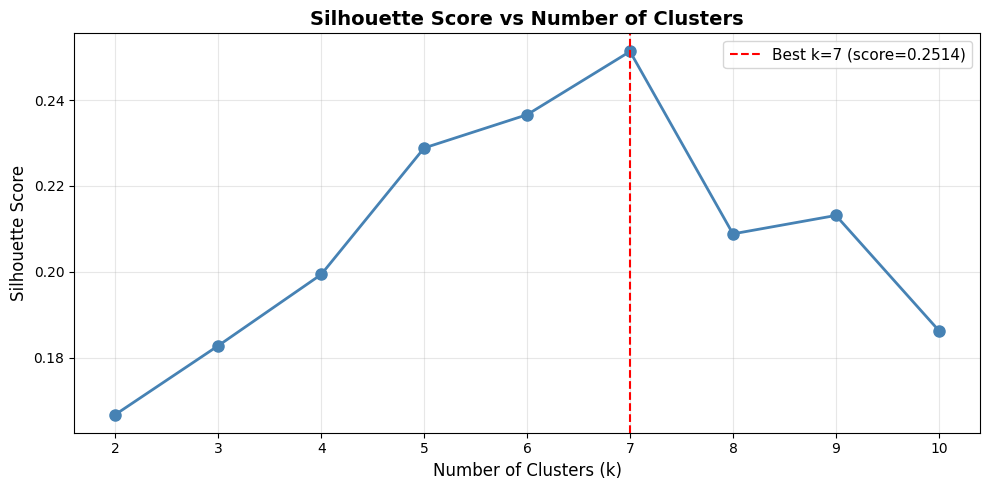

In [35]:
# Visualize Silhouette Score vs k
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(list(k_range), sil_scores, 'o-', color='steelblue', linewidth=2, markersize=8)
ax.axvline(x=best_k, color='red', linestyle='--', linewidth=1.5,
           label=f'Best k={best_k} (score={max(sil_scores):.4f})')
ax.set_title('Silhouette Score vs Number of Clusters', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Clusters (k)', fontsize=12)
ax.set_ylabel('Silhouette Score', fontsize=12)
ax.set_xticks(list(k_range))
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 5.2 Final Clustering with k=5

Apply hierarchical clustering with 5 clusters (matching the true number of cancer types) and visualize per-sample silhouette values.

In [36]:
# Final clustering: k=5
k_final = 5
final_labels = fcluster(linkage_ward, t=k_final, criterion='maxclust')
final_labels_0 = final_labels - 1

sil_final = silhouette_score(X_reduced, final_labels)
sample_sil = silhouette_samples(X_reduced, final_labels)

print(f'Final Clustering Results (k={k_final}, Ward Linkage):')
print('=' * 45)
print(f'  Average Silhouette Score: {sil_final:.4f}')
print(f'\nCluster distribution:')
unique, counts = np.unique(final_labels, return_counts=True)
for u, c in zip(unique, counts):
    cluster_sil = sample_sil[final_labels == u].mean()
    print(f'  Cluster {u}: {c:4d} patients ({c/len(final_labels)*100:.1f}%)  '
          f'| silhouette = {cluster_sil:.4f}')

Final Clustering Results (k=5, Ward Linkage):
  Average Silhouette Score: 0.2289

Cluster distribution:
  Cluster 1:  145 patients (18.1%)  | silhouette = 0.3329
  Cluster 2:  149 patients (18.6%)  | silhouette = 0.2549
  Cluster 3:  241 patients (30.1%)  | silhouette = 0.2304
  Cluster 4:   77 patients (9.6%)  | silhouette = 0.3869
  Cluster 5:  189 patients (23.6%)  | silhouette = 0.0622


---

## Summary

### Pipeline Overview

1. **Data Acquisition**: Loaded the TCGA Pan-Cancer RNA-Seq dataset from UCI -- 801 patients, 20,531 genes, 5 cancer types (BRCA, KIRC, COAD, LUAD, PRAD).

2. **Dimensionality Reduction (SVD)**: TruncatedSVD compressed data from 20,531 dimensions to 50 latent components, retaining the majority of variance while discarding noise.

3. **Hierarchical Clustering**: Applied agglomerative clustering with Ward linkage on the 50-dimensional SVD space. Dendrogram reveals clear cluster boundaries as large gaps in merge distance.

4. **Evaluation**: Silhouette Score determined optimal k and assessed per-sample cluster quality -- higher scores indicate better-separated, more cohesive clusters.